# Prediksi Resistensi Fenotipe dalam setiap Antibiotik terhadap Bakteri

## Abstraksi

## Import Library

In [307]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Modeling
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## Explanatory Data Analysis

### Mengunggah Dataset

In [308]:

df_meta = pd.read_csv('metadata.csv')
df_meta.head(5)


,Sample_ID,Year,Country,Continent,Beta.lactamase,Azithromycin,Ciprofloxacin,Ceftriaxone,Cefixime,Tetracycline,...,log2_cro_mic,log2_cfx_mic,log2_tet_mic,log2_pen_mic,azm_sr,cip_sr,cro_sr,cfx_sr,tet_sr,pen_sr
0,ERR1549286,2015.0,UK,Europe,NaN,>256,NaN,0.016,NaN,NaN,...,-5.965784,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN
1,ERR1549290,2015.0,UK,Europe,NaN,>256,NaN,0.004,NaN,NaN,...,-7.965784,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN
2,ERR1549291,2015.0,UK,Europe,NaN,>256,NaN,0.006,NaN,NaN,...,-7.380822,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN
3,ERR1549287,2015.0,UK,Europe,NaN,>256,NaN,0.006,NaN,NaN,...,-7.380822,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN
4,ERR1549288,2015.0,UK,Europe,NaN,>256,NaN,0.008,NaN,NaN,...,-6.965784,NaN,NaN,NaN,1.0,NaN,0.0,NaN,NaN,NaN


In [309]:
df_azm = pd.read_csv('azm_sr_gwas_filtered_unitigs_output.csv')
df_azm.shape

(3971, 516)

In [310]:
df_cfx = pd.read_csv('cfx_sr_gwas_filtered_unitigs_output.csv')
df_cfx.shape

(3971, 385)

In [311]:
df_cip = pd.read_csv('cip_sr_gwas_filtered_unitigs_output.csv')
df_cip.shape

(3971, 8874)

### Informasi Dataset

In [312]:
df_meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 3786 entries, 0 to 3785
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sample_ID       3786 non-null   str    
 1   Year            3536 non-null   float64
 2   Country         3785 non-null   str    
 3   Continent       3785 non-null   str    
 4   Beta.lactamase  1927 non-null   str    
 5   Azithromycin    3480 non-null   str    
 6   Ciprofloxacin   3129 non-null   str    
 7   Ceftriaxone     3436 non-null   str    
 8   Cefixime        3405 non-null   str    
 9   Tetracycline    1472 non-null   str    
 10  Penicillin      1465 non-null   str    
 11  NG_MAST         3779 non-null   str    
 12  Group           3786 non-null   int64  
 13  azm_mic         3478 non-null   float64
 14  cip_mic         3088 non-null   float64
 15  cro_mic         3434 non-null   float64
 16  cfx_mic         3401 non-null   float64
 17  tet_mic         1472 non-null   float64
 18 

In [313]:
df_meta.describe(include='all')

,Sample_ID,Year,Country,Continent,Beta.lactamase,Azithromycin,Ciprofloxacin,Ceftriaxone,Cefixime,Tetracycline,...,log2_cro_mic,log2_cfx_mic,log2_tet_mic,log2_pen_mic,azm_sr,cip_sr,cro_sr,cfx_sr,tet_sr,pen_sr
count,3786,3536.000000,3785,3785,1927,3480,3129,3436,3405,1472,...,3434.000000,3401.000000,1472.000000,1465.000000,3478.000000,3088.000000,3434.000000,3401.00000,1472.000000,1465.00000
unique,3786,NaN,65,5,5,33,45,33,31,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ERR1549286,NaN,USA,Europe,S,0.25,16,0.008,0.016,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,1121,1675,1371,698,483,585,916,230,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2010.300622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-6.203940,-5.164221,0.835492,-0.427788,0.128522,0.462435,0.001165,0.00147,0.554348,0.34744
std,NaN,4.670817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.772691,1.664672,2.337490,2.259337,0.334718,0.498668,0.034115,0.03832,0.497206,0.47632
min,NaN,1979.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-11.965784,-9.965784,-6.965784,-8.965784,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
25%,NaN,2009.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-7.965784,-6.058894,-1.000000,-2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
50%,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-6.058894,-5.965784,1.000000,-1.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.00000
75%,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-4.965784,-4.058894,2.000000,1.000000,0.000000,1.000000,0.000000,0.00000,1.000000,1.00000


In [314]:
missing = df_meta.isnull().sum()
missing_pct = (missing / len(df_meta) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)
Year,250,6.60
Country,1,0.03
Continent,1,0.03
Beta.lactamase,1859,49.10
Azithromycin,306,8.08
Ciprofloxacin,657,17.35
Ceftriaxone,350,9.24
Cefixime,381,10.06
Tetracycline,2314,61.12
Penicillin,2321,61.30


### Korelasi Antar Fitur

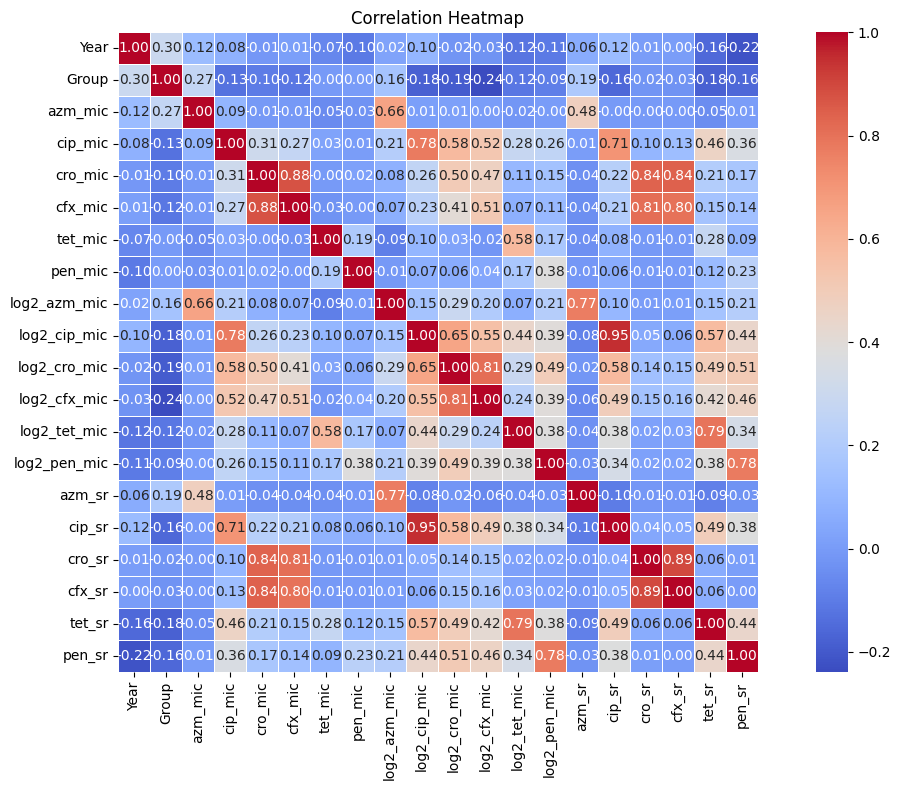

In [315]:
num_cols = df_meta.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df_meta[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Pendistribusian Setiap Fitur Numerikal

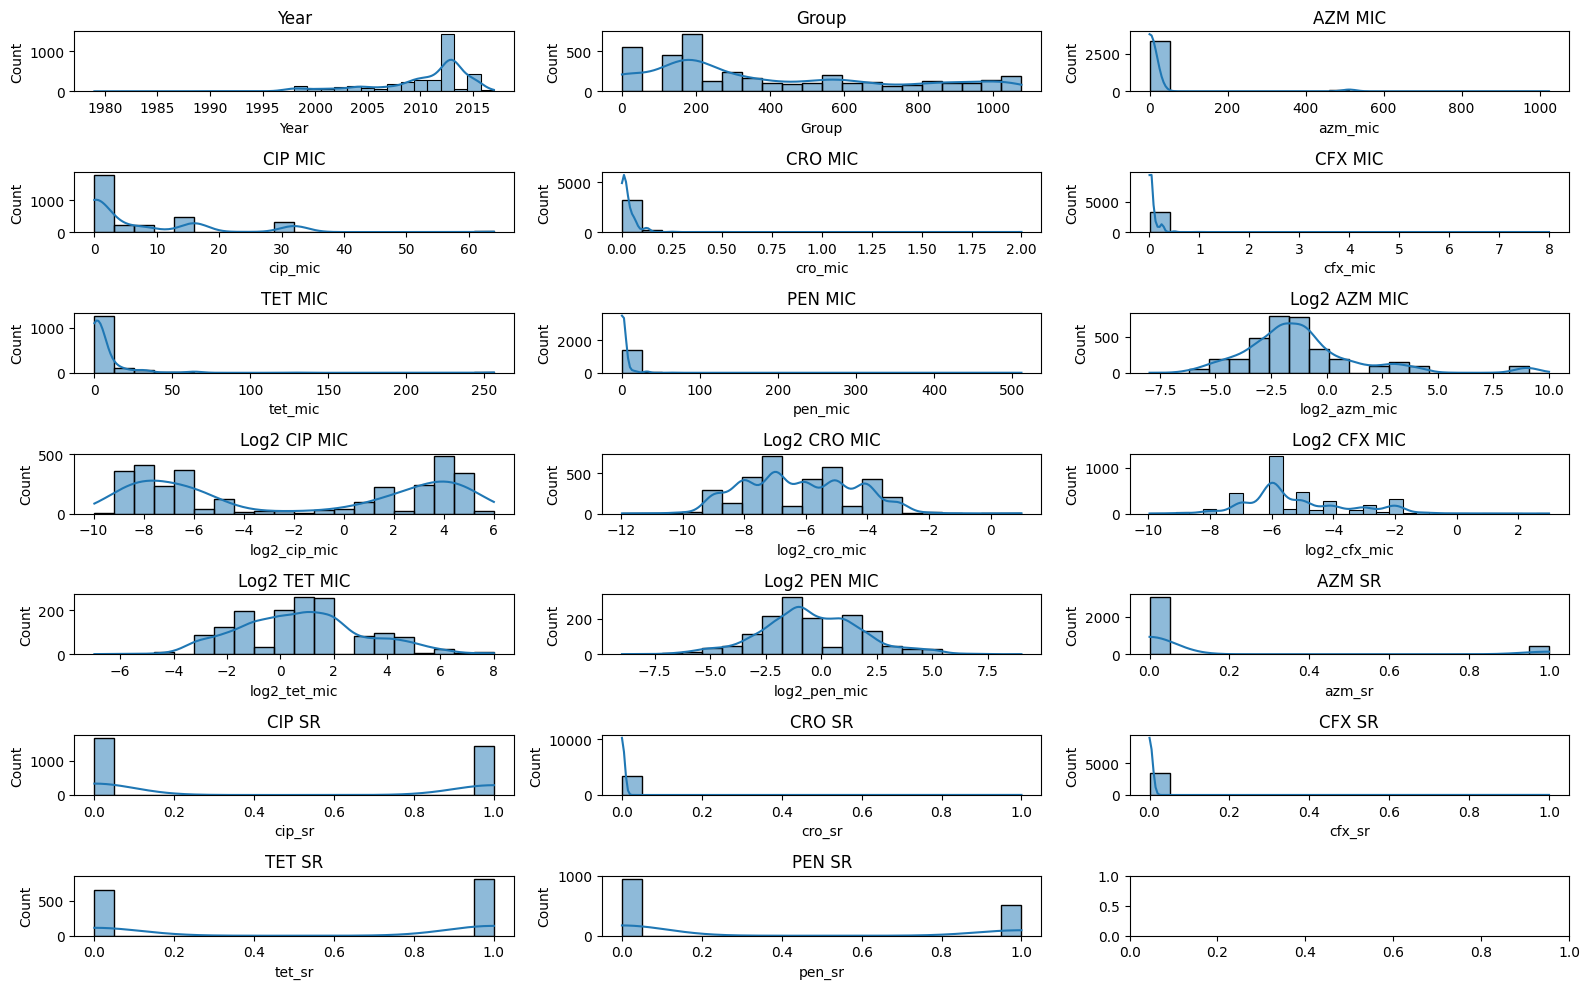

In [316]:
fig, axes = plt.subplots(7, 3, figsize=(16, 10))

sns.histplot(data=df_meta, x="Year", kde=True, ax=axes[0,0], bins=30)
axes[0,0].set_title("Year")

sns.histplot(data=df_meta, x="Group", kde=True, ax=axes[0,1], bins=20)
axes[0,1].set_title("Group")

sns.histplot(data=df_meta, x="azm_mic", kde=True, ax=axes[0,2], bins=20)
axes[0,2].set_title("AZM MIC")

sns.histplot(data=df_meta, x="cip_mic", kde=True, ax=axes[1,0], bins=20)
axes[1,0].set_title("CIP MIC")

sns.histplot(data=df_meta, x="cro_mic", kde=True, ax=axes[1,1], bins=20)
axes[1,1].set_title("CRO MIC")

sns.histplot(data=df_meta, x="cfx_mic", kde=True, ax=axes[1,2], bins=20)
axes[1,2].set_title("CFX MIC")

sns.histplot(data=df_meta, x="tet_mic", kde=True, ax=axes[2,0], bins=20)
axes[2,0].set_title("TET MIC")

sns.histplot(data=df_meta, x="pen_mic", kde=True, ax=axes[2,1], bins=20)
axes[2,1].set_title("PEN MIC")

sns.histplot(data=df_meta, x="log2_azm_mic", kde=True, ax=axes[2,2], bins=20)
axes[2,2].set_title("Log2 AZM MIC")

sns.histplot(data=df_meta, x="log2_cip_mic", kde=True, ax=axes[3,0], bins=20)
axes[3,0].set_title("Log2 CIP MIC")

sns.histplot(data=df_meta, x="log2_cro_mic", kde=True, ax=axes[3,1], bins=20)
axes[3,1].set_title("Log2 CRO MIC")

sns.histplot(data=df_meta, x="log2_cfx_mic", kde=True, ax=axes[3,2], bins=30)
axes[3,2].set_title("Log2 CFX MIC")

sns.histplot(data=df_meta, x="log2_tet_mic", kde=True, ax=axes[4,0], bins=20)
axes[4,0].set_title("Log2 TET MIC")

sns.histplot(data=df_meta, x="log2_pen_mic", kde=True, ax=axes[4,1], bins=20)
axes[4,1].set_title("Log2 PEN MIC")

sns.histplot(data=df_meta, x="azm_sr", kde=True, ax=axes[4,2], bins=20)
axes[4,2].set_title("AZM SR")

sns.histplot(data=df_meta, x="cip_sr", kde=True, ax=axes[5,0], bins=20)
axes[5,0].set_title("CIP SR")
sns.histplot(data=df_meta, x="cro_sr", kde=True, ax=axes[5,1], bins=20)
axes[5,1].set_title("CRO SR")
sns.histplot(data=df_meta, x="cfx_sr", kde=True, ax=axes[5,2], bins=20)
axes[5,2].set_title("CFX SR")
sns.histplot(data=df_meta, x="tet_sr", kde=True, ax=axes[6,0], bins=20)
axes[6,0].set_title("TET SR")
sns.histplot(data=df_meta, x="pen_sr", kde=True, ax=axes[6,1], bins=20)
axes[6,1].set_title("PEN SR")

plt.tight_layout()
plt.show()

### Pendistribusian Setiap Fitur Kategorikal

Text(0.5, 1.0, 'Penicillin')

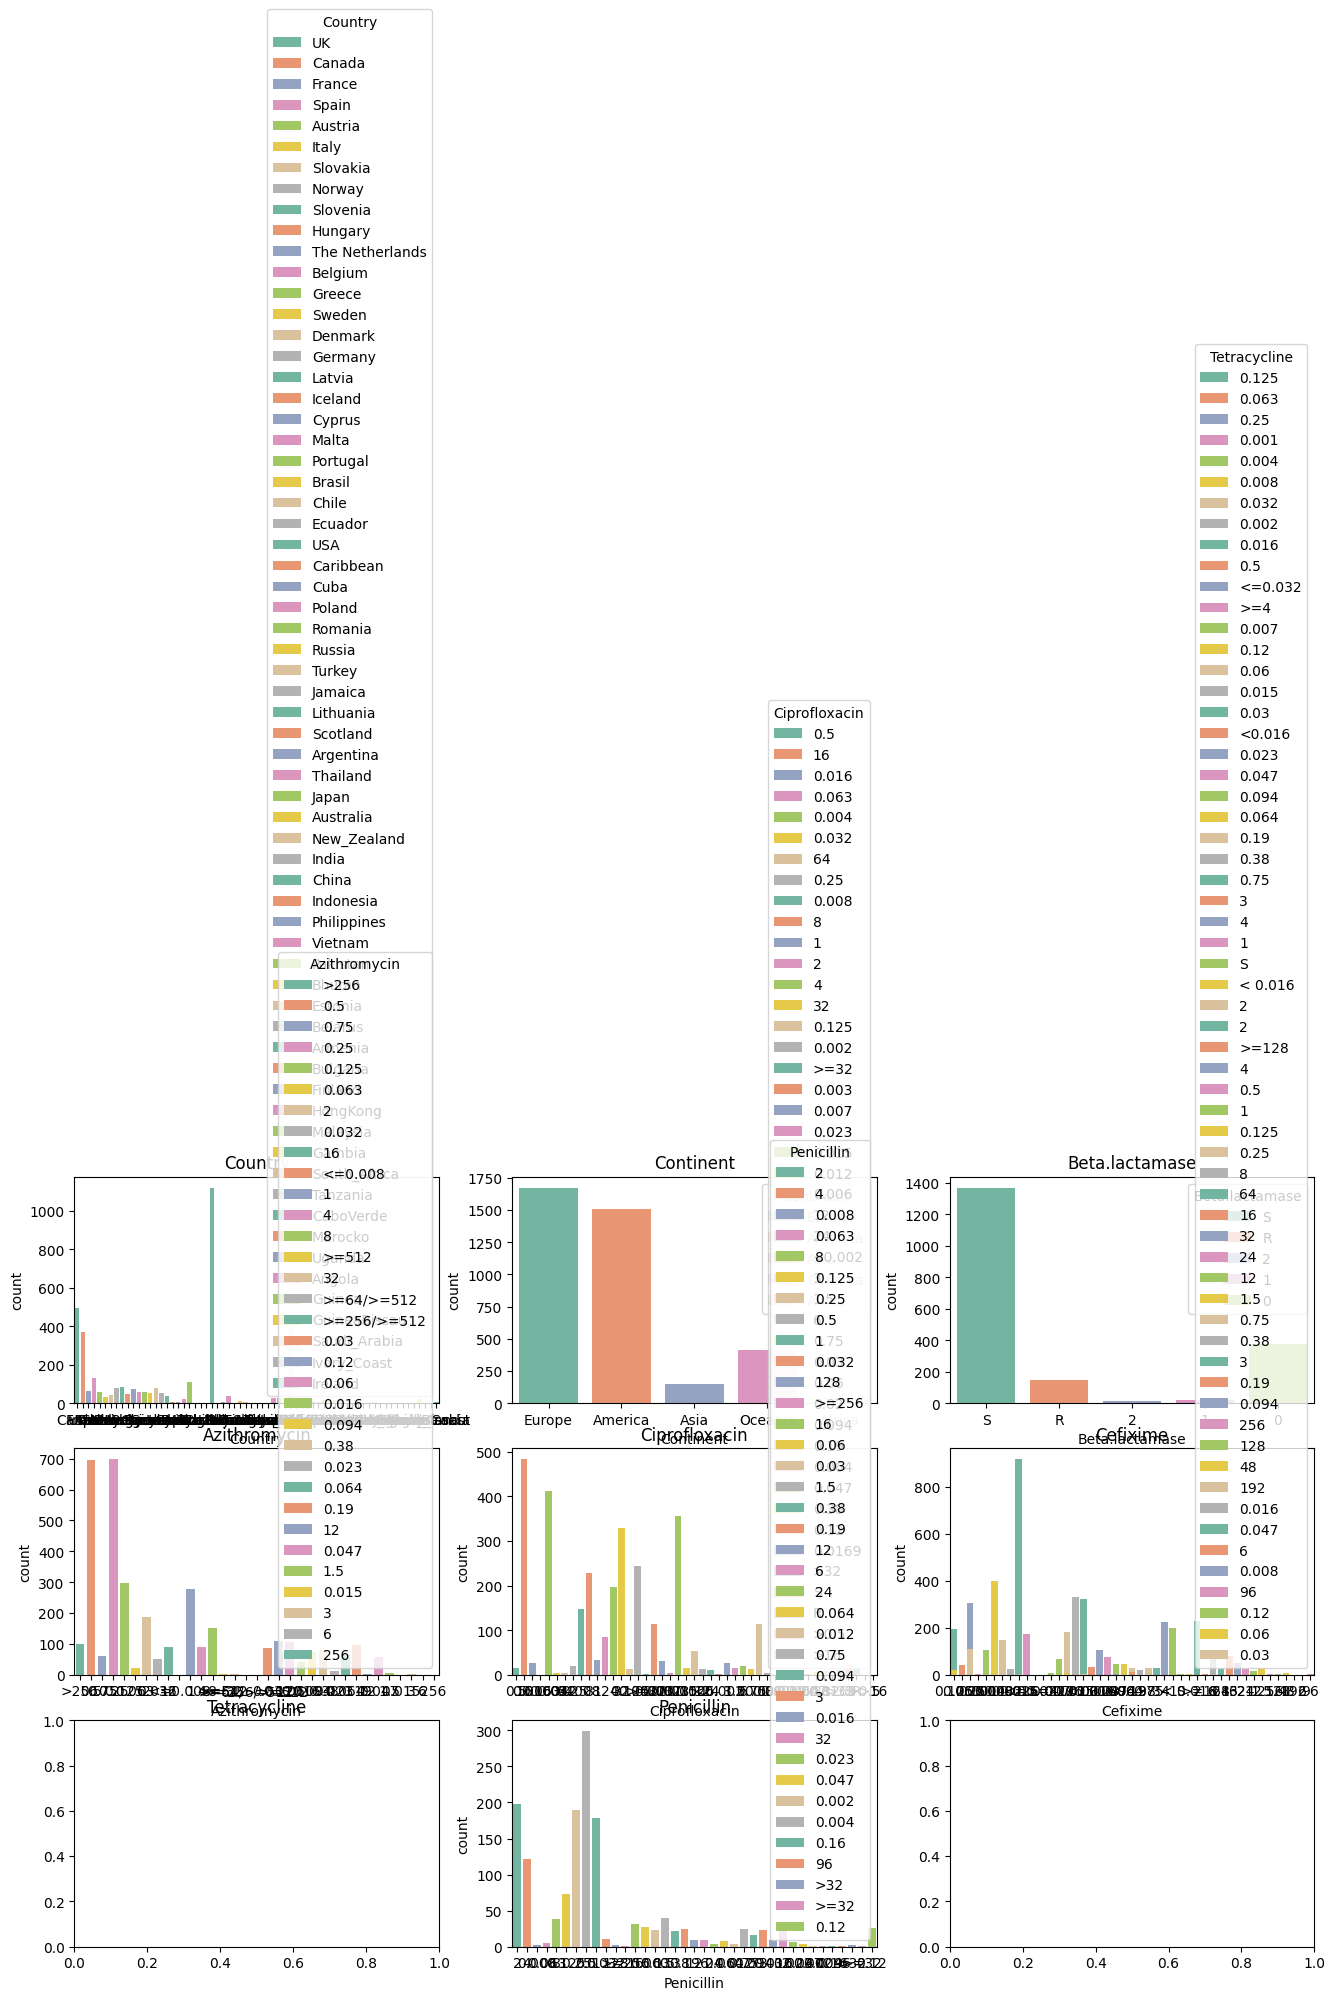

In [317]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

sns.countplot(data=df_meta, x="Country",  ax=axes[0,0], palette="Set2", hue="Country")
axes[0,0].set_title("Country")

sns.countplot(data=df_meta, x="Continent",  ax=axes[0,1], palette="Set2", hue="Continent")
axes[0,1].set_title("Continent")

sns.countplot(data=df_meta, x="Beta.lactamase",  ax=axes[0,2], palette="Set2", hue="Beta.lactamase")
axes[0,2].set_title("Beta.lactamase")

sns.countplot(data=df_meta, x="Azithromycin",  ax=axes[1,0], palette="Set2", hue="Azithromycin")
axes[1,0].set_title("Azithromycin")

sns.countplot(data=df_meta, x="Ciprofloxacin",  ax=axes[1,1], palette="Set2", hue="Ciprofloxacin")
axes[1,1].set_title("Ciprofloxacin")

sns.countplot(data=df_meta, x="Cefixime",  ax=axes[1,2], palette="Set2", hue="Cefixime")
axes[1,2].set_title("Cefixime")

sns.countplot(data=df_meta, x="Tetracycline",  ax=axes[1,2], palette="Set2", hue="Tetracycline")
axes[2,0].set_title("Tetracycline")

sns.countplot(data=df_meta, x="Penicillin",  ax=axes[2,1], palette="Set2", hue="Penicillin")
axes[2,1].set_title("Penicillin")


## Preprosssing Data

In [318]:
CAT_COLS = df_meta.select_dtypes(include='object').columns.tolist()
NUM_COLS = df_meta.select_dtypes(include=np.number).columns.tolist()
TARGET_COL = 'Beta.lactamase'
ID_COL = 'Sample_ID'


In [319]:
NUM_COLS = [c for c in df_meta.columns if c not in CAT_COLS + [TARGET_COL, ID_COL]]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

Categorical: ['Sample_ID', 'Country', 'Continent', 'Beta.lactamase', 'Azithromycin', 'Ciprofloxacin', 'Ceftriaxone', 'Cefixime', 'Tetracycline', 'Penicillin', 'NG_MAST']
Numerical:   ['Year', 'Group', 'azm_mic', 'cip_mic', 'cro_mic', 'cfx_mic', 'tet_mic', 'pen_mic', 'log2_azm_mic', 'log2_cip_mic', 'log2_cro_mic', 'log2_cfx_mic', 'log2_tet_mic', 'log2_pen_mic', 'azm_sr', 'cip_sr', 'cro_sr', 'cfx_sr', 'tet_sr', 'pen_sr']


### Handling Missing Values

In [320]:
num_imputer = SimpleImputer(strategy='median')
df_meta[NUM_COLS] = num_imputer.fit_transform(df_meta[NUM_COLS])

cat_imputer = SimpleImputer(strategy='most_frequent')
df_meta[CAT_COLS] = cat_imputer.fit_transform(df_meta[CAT_COLS])

### Encoding Fitur Kategorik

In [321]:
le = LabelEncoder()
LABEL_CAT_COLS = ["Continent"]
ONE_CAT_COLS = ["Country", "Azithromycin", "Ciprofloxacin", "Ceftriaxone", "Cefixime", "Tetracycline", "Penicillin", "NG_MAST"]

for col in LABEL_CAT_COLS:
    le.fit(df_meta[col].astype(str))
    df_meta[col] = le.transform(df_meta[col].astype(str))

df_meta = pd.get_dummies(df_meta, columns=ONE_CAT_COLS, drop_first=True)

### Feature Scaling

In [322]:
MINMAX_NUM_COLS = ["Year", "Group", "azm_mic", "cip_mic", "cro_mic", "cfx_mic", "tet_mic", "pen_mic", "azm_sr", "cip_sr", "cro_sr", "cfx_sr", "tet_sr", "pen_sr" ]
STANDARD_NUM_COLS = ["log2_azm_mic", "log2_cro_mic", "log2_cip_mic", "log2_tet_mic", "log2_pen_mic"]

standar_scaler = StandardScaler()
df_meta[STANDARD_NUM_COLS] = standar_scaler.fit_transform(df_meta[STANDARD_NUM_COLS])

minmax_scaler = MinMaxScaler()
df_meta[MINMAX_NUM_COLS] = standar_scaler.fit_transform(df_meta[MINMAX_NUM_COLS])


# 3. Train/Test Split, 80% untuk Training, Sisanya untuk Testing

In [323]:
X = df_meta.drop(columns=ID_COL + [TARGET_COL])
y = df_meta[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTraining set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")

TypeError: can only concatenate str (not "list") to str

# 4. Model Training

# 5. Evaluate On Test Set

# 6. Confusion Matrix

NameError: name 'y_pred' is not defined

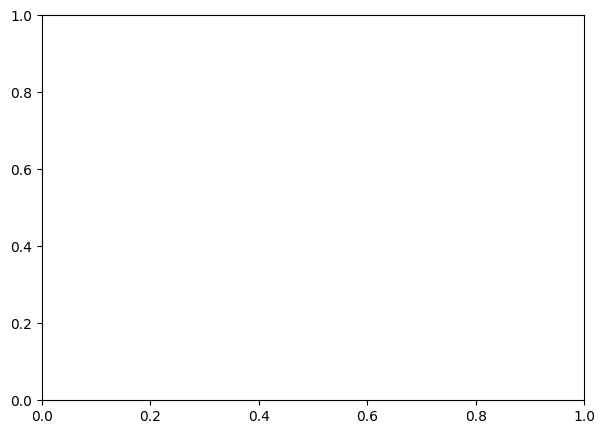

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title("Confusion Matrix: Resistance Phenotype Prediction", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# 7. Feature Importance

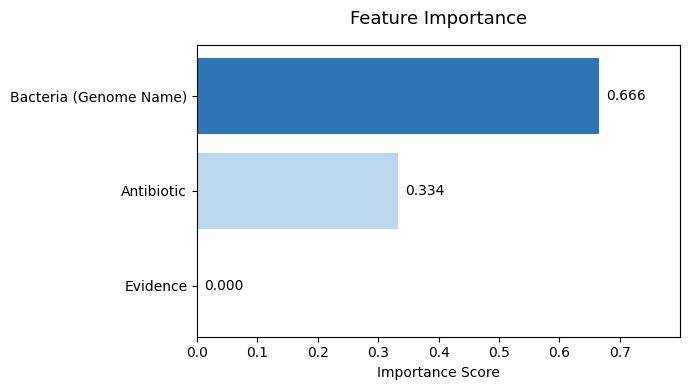

In [ ]:
importances = model.feature_importances_
features    = ['Bacteria (Genome Name)', 'Antibiotic', 'Evidence']

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2E75B6' if i == np.argmax(importances) else '#BDD7EE' for i in range(len(features))]
bars = ax.barh(features, importances, color=colors)
ax.bar_label(bars, fmt='%.3f', padding=5)
ax.set_xlim(0, max(importances) * 1.2)
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance", fontsize=13, pad=15)
ax.invert_yaxis()
plt.tight_layout()
plt.show()